# 06 -- Robustness to noise

Every model so far was trained and tested on the Watkins archive's
recordings as-is: many were made relatively close to the animal (this is
a "best of" curated archive, not raw continuous monitoring). Real passive
sonar / passive acoustic monitoring deployments rarely get that courtesy:
signal strength falls off with range (spreading + absorption loss), sea
state adds broadband noise, and the platform/sensor itself contributes
self-noise -- on top of this archive's own old-tape hiss and hum for its
oldest recordings. A classifier that only works at this archive's
generally-favorable SNR isn't yet telling you much about deployed
performance on a distant, quiet animal.

This notebook takes each trained checkpoint and asks: what happens to
accuracy as we synthetically degrade the test clips with added noise at
progressively worse signal-to-noise ratios? `watkins.robustness` does
this by injecting **white** or **pink** noise directly into the raw
waveform (before any feature extraction), at a target SNR relative to
the clip's own power -- see `watkins/augment.py` for the implementation
and rationale (pink noise, with its 1/f spectral shape, is a closer
match to real ambient ocean noise than white noise).

In [ ]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/ShipsEAR"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from watkins.robustness import robustness_sweep, DEFAULT_SNR_LEVELS_DB
from watkins.utils import results_root

RESULTS = results_root()
RUN_NAMES = ["baseline_cnn", "resnet18", "efficientnet_b0", "ast_linear_probe"]


## 1. Load (or run) the robustness sweep for every model

If you already ran `python -m watkins.robustness --checkpoint
results/checkpoints/<run_name>_best.pt` for each model, this just loads
the saved CSVs. Otherwise it runs the sweep now (a handful of forward
passes over the test set per SNR level -- much cheaper than training).

In [2]:
dfs = {}
for run_name in RUN_NAMES:
    csv_path = RESULTS / "metrics" / f"{run_name}_robustness.csv"
    if csv_path.exists():
        dfs[run_name] = pd.read_csv(csv_path)
    else:
        ckpt_path = RESULTS / "checkpoints" / f"{run_name}_best.pt"
        if not ckpt_path.exists():
            print(f"skipping {run_name}: no checkpoint at {ckpt_path}")
            continue
        dfs[run_name] = robustness_sweep(str(ckpt_path))

list(dfs.keys())


skipping baseline_cnn: no checkpoint at ../results/checkpoints/baseline_cnn_best.pt
skipping resnet18: no checkpoint at ../results/checkpoints/resnet18_best.pt
skipping efficientnet_b0: no checkpoint at ../results/checkpoints/efficientnet_b0_best.pt
skipping ast_linear_probe: no checkpoint at ../results/checkpoints/ast_linear_probe_best.pt


[]

## 2. Accuracy vs. SNR, all models on one plot

Steeper drop-offs mean a model relies more on fine acoustic detail that
noise wipes out first; flatter curves mean the model is using more
robust, coarse-grained cues (e.g. overall energy level, broad spectral
shape) that survive degradation better -- though that robustness can
also just mean the model was already leaning on shortcuts rather than
genuinely discriminative features. Which explanation fits depends on
what you see in the per-class breakdown below.

/tmp/ipykernel_33476/2369664933.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


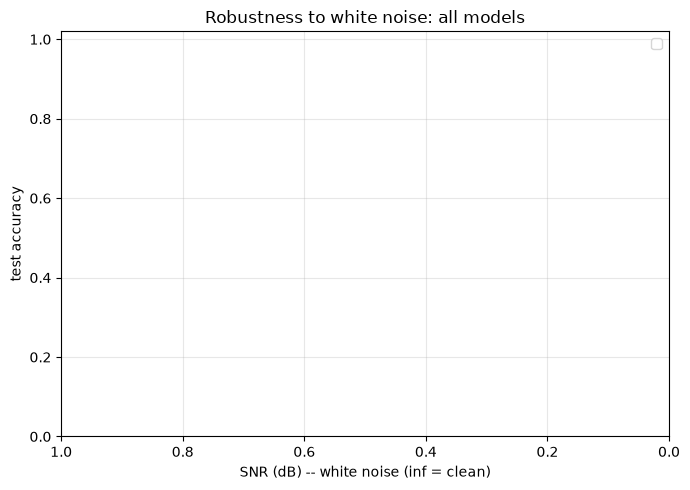

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for run_name, df in dfs.items():
    white = df[(df["noise_kind"] == "white") | (df["snr_db"] == float("inf"))]
    white = white.drop_duplicates(subset="snr_db").sort_values("snr_db")
    ax.plot(white["snr_db"], white["accuracy"], marker="o", label=run_name)
ax.set_xlabel("SNR (dB) -- white noise (inf = clean)")
ax.set_ylabel("test accuracy")
ax.set_title("Robustness to white noise: all models")
ax.invert_xaxis()
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Per-class robustness: who falls apart first?

Aggregate accuracy can hide a lot. With 54 severely imbalanced species,
there's a specific degenerate failure mode to watch for: at very low SNR,
does the model's accuracy on **killer whale** or **sperm whale** (the two
largest species by clip count) stay suspiciously high while every rarer
species collapses toward 0? If so, that's very likely **not** robustness
-- it's the model collapsing to predicting the majority species for
everything once the signal is buried, which happens to still score
"correct" a lot of the time (killer whale is ~28% of the data) while
being uninformative everywhere else. Distinguishing genuine robustness
from this kind of degenerate collapse is exactly why per-class metrics
matter more than aggregate accuracy for a monitoring-relevant
classifier.

In [4]:
if not dfs:
    print("No robustness sweeps available yet -- train and evaluate at least one model first.")
else:
    acc_cols = [c for c in next(iter(dfs.values())).columns if c.startswith("acc_")]
    majority_cols = [c for c in acc_cols if c.replace("acc_", "") in ("KillerWhale", "SpermWhale")]
    other_cols = [c for c in acc_cols if c not in majority_cols]

    fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4.5), sharey=True)
    if len(dfs) == 1:
        axes = [axes]
    for ax, (run_name, df) in zip(axes, dfs.items()):
        white = df[(df["noise_kind"] == "white") | (df["snr_db"] == float("inf"))]
        white = white.drop_duplicates(subset="snr_db").sort_values("snr_db")
        for col in other_cols:
            ax.plot(white["snr_db"], white[col], marker=".", linewidth=0.6, alpha=0.5, color="gray")
        for col in majority_cols:
            if col in white.columns:
                ax.plot(white["snr_db"], white[col], marker="o", linewidth=2, label=col.replace("acc_", ""))
        ax.set_title(run_name, fontsize=10)
        ax.set_xlabel("SNR (dB)")
        ax.invert_xaxis()
        ax.set_ylim(0, 1.02)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("per-species accuracy\n(gray = other species, colored = majority species)")
    plt.tight_layout()
    plt.show()


No robustness sweeps available yet -- train and evaluate at least one model first.


## 4. White vs. pink noise: does the noise color matter?

In [5]:
if not dfs:
    print("No robustness sweeps available yet -- train and evaluate at least one model first.")
else:
    run_name = RUN_NAMES[0] if RUN_NAMES[0] in dfs else next(iter(dfs))
    df = dfs[run_name]
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for noise_kind, group in df[df["snr_db"] != float("inf")].groupby("noise_kind"):
        group = group.sort_values("snr_db")
        ax.plot(group["snr_db"], group["accuracy"], marker="o", label=noise_kind)
    clean_acc = df[df["snr_db"] == float("inf")]["accuracy"].iloc[0]
    ax.axhline(clean_acc, linestyle="--", color="gray", label="clean")
    ax.set_title(f"{run_name}: white vs. pink noise")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("accuracy")
    ax.invert_xaxis()
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


No robustness sweeps available yet -- train and evaluate at least one model first.


## Exercises

1. Which model degrades most gracefully (smallest area lost under the
   accuracy-vs-SNR curve)? Is it the same model that had the best clean
   accuracy in notebook 05, or does the ranking change under noise? A
   ranking change is an important, easy-to-miss result: it means "best
   on the leaderboard" and "best for a real deployment" aren't the same
   question.
2. Extend `DEFAULT_SNR_LEVELS_DB` in `watkins/robustness.py` (or pass
   `snr_levels_db=` directly to `robustness_sweep`) down to -20dB. Given
   killer whale alone is ~28% of the training data (not a uniform
   1/54 chance), does any model hold up meaningfully better than "always
   predict killer whale" even at extreme noise?
3. Retrain the baseline CNN with `noise_augment_p: 0.0` (no training-time
   noise augmentation) and rerun its robustness sweep. Does removing
   augmentation hurt clean accuracy, robustness, or both?
4. (Bonus, ties back to notebook 01) Instead of synthetic white/pink
   noise, try mixing in a *real* clip from a different, common species
   (e.g. killer whale) at a target SNR as the "noise" signal, using
   `watkins.augment.mix_at_snr` directly -- a rough proxy for a
   multi-animal acoustic scene. Does it degrade models differently than
   white/pink noise does?
5. See `docs/next_steps.md` for further extensions: multi-species
   mixtures ("cocktail party" separation), streaming/online inference,
   and a higher-sample-rate variant that doesn't discard odontocete
   ultrasonic content in the first place.